# 小费数据预处理

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 设置Matplotlib正常显示中文和负号
plt.rcParams['font.sans-serif']=['SimHei']   # 用黑体显示中文
plt.rcParams['axes.unicode_minus']=False     # 正常显示负号

In [2]:
fdata=pd.read_excel('C:/dataset/tips_mod.xls')
fdata

,消费总额,小费,性别,是否抽烟,星期,聚餐时间段,人数
0,16.99,1.01,Female,No,Sun,Dinner,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2.0
4,24.59,3.61,Female,No,Sun,Dinner,4.0
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2.0
242,17.82,1.75,Male,No,Sat,Dinner,2.0


In [3]:
fdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   消费总额    241 non-null    float64
 1   小费      241 non-null    float64
 2   性别      242 non-null    object 
 3   是否抽烟    244 non-null    object 
 4   星期      242 non-null    object 
 5   聚餐时间段   242 non-null    object 
 6   人数      242 non-null    float64
dtypes: float64(3), object(4)
memory usage: 13.5+ KB


In [4]:
fdata.isnull().sum()

消费总额     3
小费       3
性别       2
是否抽烟     0
星期       2
聚餐时间段    2
人数       2
dtype: int64

In [5]:
# 检测数据中的缺失值
fdata.isnull().sum()

消费总额     3
小费       3
性别       2
是否抽烟     0
星期       2
聚餐时间段    2
人数       2
dtype: int64

# 删除一行内有两个缺失值的数据
目标：删除每行中缺失值数量 ≥2 的行。
等价条件：保留每行中非缺失值数量 ≥6 的行（因为总列数为 7，允许最多 1 个缺失值）。
thresh = 总列数 - 允许的最大缺失值数 = 7 - 1 = 6

In [6]:
fdata.dropna(thresh=6,inplace=True)
print(fdata.isnull().sum())
fdata

消费总额     1
小费       1
性别       0
是否抽烟     0
星期       1
聚餐时间段    2
人数       2
dtype: int64


,消费总额,小费,性别,是否抽烟,星期,聚餐时间段,人数
0,16.99,1.01,Female,No,Sun,Dinner,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2.0
4,24.59,3.61,Female,No,Sun,Dinner,4.0
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2.0
242,17.82,1.75,Male,No,Sat,Dinner,2.0


In [7]:
# a = fdata.dropna(thresh=len(fdata.columns))  #同学们错误示例
# print(a)

# 删除性别或者聚餐时间为空的行

In [8]:
fdata.dropna(subset=['性别','聚餐时间段'],inplace=True)
print(fdata.isnull().sum())
fdata

消费总额     1
小费       1
性别       0
是否抽烟     0
星期       1
聚餐时间段    0
人数       2
dtype: int64


,消费总额,小费,性别,是否抽烟,星期,聚餐时间段,人数
0,16.99,1.01,Female,No,Sun,Dinner,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2.0
4,24.59,3.61,Female,No,Sun,Dinner,4.0
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2.0
242,17.82,1.75,Male,No,Sat,Dinner,2.0


In [9]:
# subset_columns = ['性别','聚餐时间段']      #同学们错误示例
# b = fdata.dropna(subset=subset_columns)
# print(b)

In [10]:
# 对剩余空缺的数据用平均值替代
# fdata.fillna(fdata.mean(),inplace=True)
# fdata.isnull().sum()

In [11]:
fdata.describe()

,消费总额,小费,人数
count,238.000000,238.000000,237.000000
mean,19.968025,3.005924,2.578059
std,8.913450,1.385734,0.960680
min,3.070000,1.000000,1.000000
25%,13.397500,2.000000,2.000000
50%,17.855000,2.900000,2.000000
75%,24.457500,3.507500,3.000000
max,50.810000,10.000000,6.000000


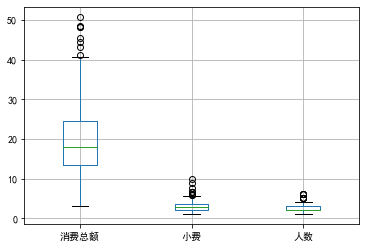

In [12]:
fdata.boxplot();

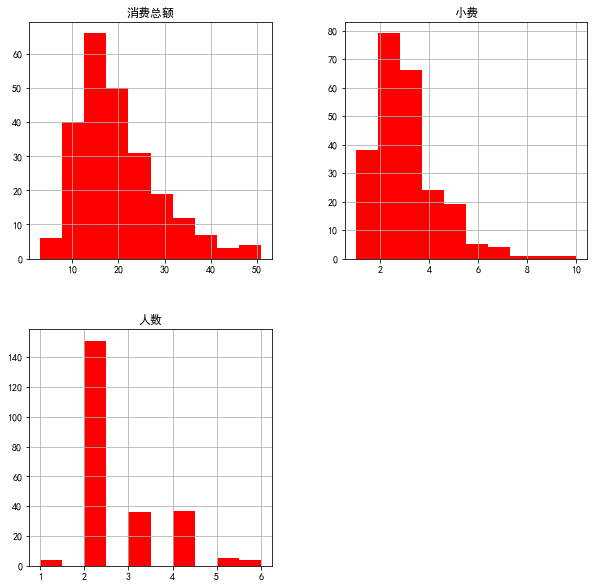

In [13]:
fdata.hist(figsize=(10,10),color='red');

(array([  4.,   0., 151.,   0.,  36.,   0.,  37.,   0.,   5.,   4.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

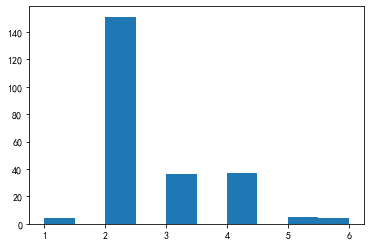

In [14]:
plt.hist(fdata.人数)

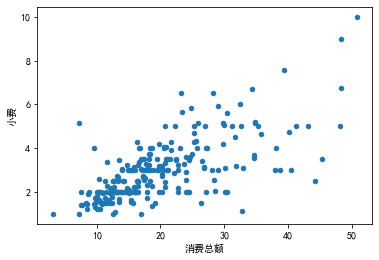

In [15]:
#分析小费和总金额的关系,散点图
fdata.plot(kind='scatter',x='消费总额',y='小费');
#正相关关系

In [16]:
#分析男女顾客哪个更慷慨，就是分组看看男性还是女性的小费平均水平更高
fdata.groupby('性别')['小费'].mean()
# 从分析结果可以看出，男性顾客明显慷慨一些。

性别
Female    2.855238
Male      3.088117
Name: 小费, dtype: float64

['Sun' 'Sat' nan 'Thur' 'Fri']


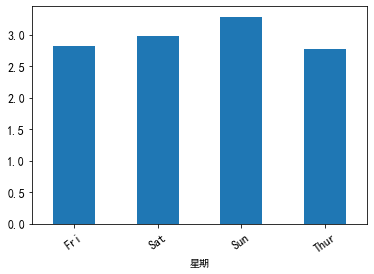

In [17]:
#分析星期和小费的关系，直方图
print(fdata['星期'].unique())
r=fdata.groupby('星期')['小费'].mean()
r.plot(kind='bar',x='星期',y='小费',fontsize=12,rot=36);
